In [ ]:
#Import libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [ ]:
#Load Data & Aggregate to Monthly Frequency

In [2]:
df = pd.read_csv('C:/Users/Mindworx/Downloads/adidas_dataset.csv')

In [3]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

In [5]:
print(df['Order_Date'])

0      2024-09-21
1      2024-09-04
2      2024-09-24
3      2024-01-03
4      2023-10-07
          ...    
1195   2024-12-14
1196   2023-06-12
1197   2023-06-19
1198   2023-09-03
1199   2025-08-06
Name: Order_Date, Length: 1200, dtype: datetime64[ns]


In [6]:
#Regroup daily lines into clean monthly sums

In [8]:
ts_data = df.groupby(df['Order_Date'].dt.to_period('M'))['Revenue'].sum().reset_index()
ts_data['Order_Date'] = ts_data['Order_Date'].dt.to_timestamp()
ts_data.set_index('Order_Date', inplace=True)
ts_data = ts_data.asfreq('MS') # Establish Explicit Month-Start Frequency
print(ts_data)

             Revenue
Order_Date          
2023-01-01   8841.15
2023-02-01   4211.32
2023-03-01   7985.01
2023-04-01  12515.29
2023-05-01   9064.79
2023-06-01   7146.25
2023-07-01   8782.35
2023-08-01   8107.39
2023-09-01   9372.61
2023-10-01  12775.49
2023-11-01   8672.51
2023-12-01   9874.27
2024-01-01  10026.96
2024-02-01   6106.71
2024-03-01  12667.48
2024-04-01   5660.27
2024-05-01  11431.88
2024-06-01   8589.02
2024-07-01   7167.15
2024-08-01   7369.32
2024-09-01   7961.61
2024-10-01   7454.29
2024-11-01   7457.03
2024-12-01  11338.03
2025-01-01   7163.28
2025-02-01   8547.43
2025-03-01   8990.68
2025-04-01   7592.40
2025-05-01   9179.60
2025-06-01   9746.06
2025-07-01   6539.32
2025-08-01   8158.16
2025-09-01  10882.81


In [ ]:
#Perform Time-Series Decomposition

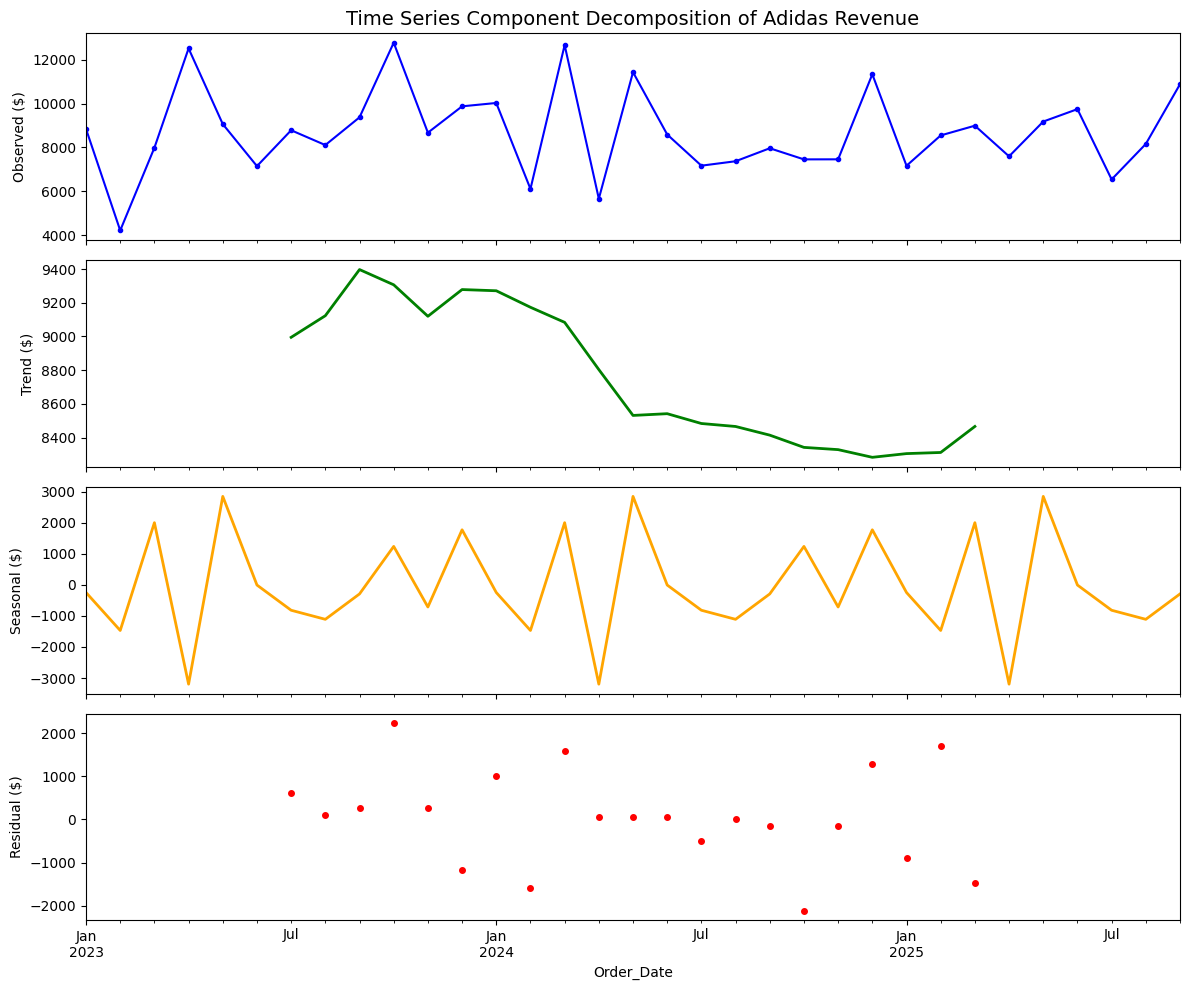

In [10]:
decomposition = seasonal_decompose(ts_data['Revenue'], model='additive', period=12)

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
decomposition.observed.plot(ax=ax1, color='b', marker='.')
ax1.set_ylabel('Observed ($)')
ax1.set_title('Time Series Component Decomposition of Adidas Revenue', fontsize=14)

decomposition.trend.plot(ax=ax2, color='g', linewidth=2)
ax2.set_ylabel('Trend ($)')

decomposition.seasonal.plot(ax=ax3, color='orange', linewidth=2)
ax3.set_ylabel('Seasonal ($)')

decomposition.resid.plot(ax=ax4, color='r', style='o', markersize=4)
ax4.set_ylabel('Residual ($)')
plt.tight_layout()


In [ ]:
#Fit Holt-Winters Exponential Smoothing & Project Next 12 Months

In [11]:
model = ExponentialSmoothing(ts_data['Revenue'], trend='add', seasonal='add', seasonal_periods=12)
fitted_model = model.fit()

In [12]:
# Project out 12 steps into the future
forecast_steps = 12
forecast = fitted_model.forecast(steps=forecast_steps)

In [13]:
# Save results to disk
forecast_df = forecast.reset_index()
forecast_df.columns = ['Forecast_Month', 'Forecasted_Revenue']
forecast_df.to_csv('revenue_forecast_results.csv', index=False)

In [ ]:
#Generate the Visualization Dashboard

Time-series forecasting script run successfully!


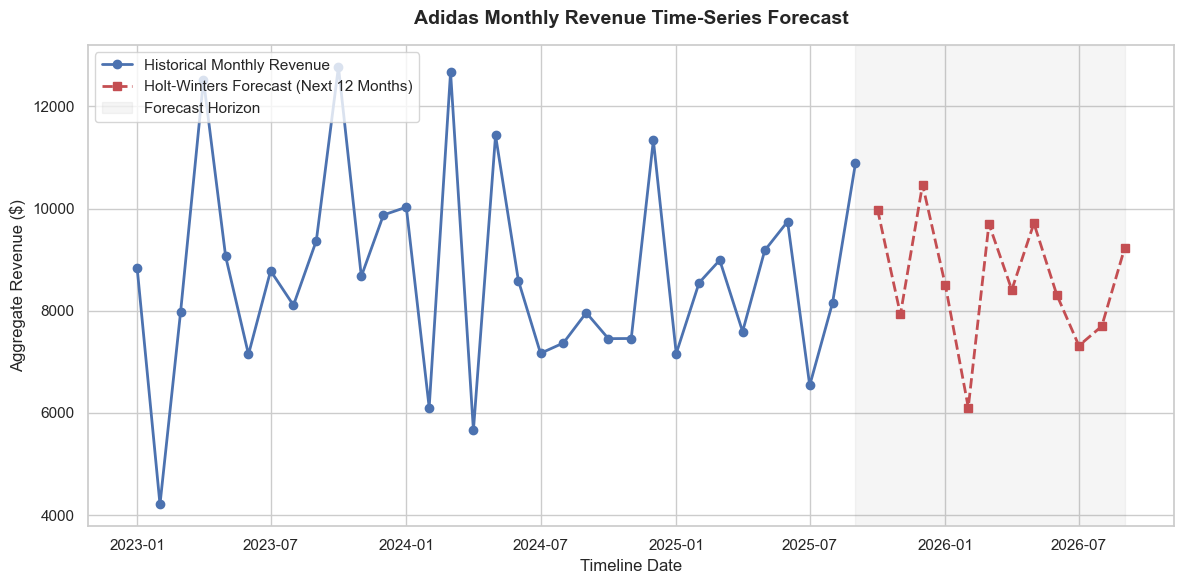

In [15]:
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(ts_data.index, ts_data['Revenue'], marker='o', color='b', label='Historical Monthly Revenue', linewidth=2)
ax.plot(forecast.index, forecast, marker='s', linestyle='--', color='r', label='Holt-Winters Forecast (Next 12 Months)', linewidth=2)
ax.axvspan(ts_data.index[-1], forecast.index[-1], color='gray', alpha=0.08, label='Forecast Horizon')

ax.set_title('Adidas Monthly Revenue Time-Series Forecast', fontsize=14, pad=15, weight='bold')
ax.set_xlabel('Timeline Date', fontsize=12)
ax.set_ylabel('Aggregate Revenue ($)', fontsize=12)
ax.legend(fontsize=11, loc='upper left')

plt.tight_layout()

print("Time-series forecasting script run successfully!")